**Import Data dan Standarisasi**

In [1]:
# ── Import Library ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

**DataSet Tawa Tengah Dalam Angka 2024**

In [2]:
df = pd.read_csv('DataSet_UTS_MPML.csv')
print(f'Dimensi dataset : {df.shape[0]} observasi x {df.shape[1]} variabel')
print(f'Level observasi : Kabupaten/Kota')
print(f'Tahun data      : 2023')
print(f'Sumber          : BPS Jawa Tengah Dalam Angka 2024')
df.head(10)

Dimensi dataset : 35 observasi x 6 variabel
Level observasi : Kabupaten/Kota
Tahun data      : 2023
Sumber          : BPS Jawa Tengah Dalam Angka 2024


,kabupaten_kota,kategori,RLS,PDRB_perkapita_ribu,persen_miskin,kepadatan_penduduk
0,Cilacap,Kabupaten,7.39,65954.48,10.99,864
1,Banyumas,Kabupaten,7.87,37598.53,12.53,1314
2,Purbalingga,Kabupaten,7.34,30393.79,14.99,1275
3,Banjarnegara,Kabupaten,6.86,25964.62,14.90,915
4,Kebumen,Kabupaten,7.86,25590.27,16.34,1048
5,Purworejo,Kabupaten,8.46,29416.54,11.33,729
6,Wonosobo,Kabupaten,6.89,25646.75,15.58,899
7,Magelang,Kabupaten,7.82,30571.68,10.96,1178
8,Boyolali,Kabupaten,8.09,39202.29,9.81,994
9,Klaten,Kabupaten,9.27,39921.17,12.28,1839


**Tipe Data Tiap Variabel**

In [3]:
df.info()
print('\n')
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   kabupaten_kota       35 non-null     object 
 1   kategori             35 non-null     object 
 2   RLS                  35 non-null     float64
 3   PDRB_perkapita_ribu  35 non-null     float64
 4   persen_miskin        35 non-null     float64
 5   kepadatan_penduduk   35 non-null     int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 1.8+ KB




,RLS,PDRB_perkapita_ribu,persen_miskin,kepadatan_penduduk
count,35.00,35.00,35.00,35.00
mean,8.25,48331.90,10.40,2065.80
std,1.31,31303.45,3.26,2390.56
min,6.40,21235.60,4.23,461.00
25%,7.36,28804.45,7.63,925.00
50%,7.86,36550.97,9.81,1172.00
75%,9.13,50755.96,12.40,1760.50
max,11.24,146867.46,16.34,11277.00


**Cek Missing Value**

In [4]:
print('=== MISSING VALUE PER VARIABEL ===')
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': pct,
                   'Status': ['Lengkap' if v == 0 else 'Ada Missing' for v in missing]})
print(mv.to_string())
print(f'\nTotal missing value: {missing.sum()}')
print('Kesimpulan: Dataset bersih, tidak diperlukan imputasi.')

=== MISSING VALUE PER VARIABEL ===
                     Jumlah Missing  Persentase (%)   Status
kabupaten_kota                    0             0.0  Lengkap
kategori                          0             0.0  Lengkap
RLS                               0             0.0  Lengkap
PDRB_perkapita_ribu               0             0.0  Lengkap
persen_miskin                     0             0.0  Lengkap
kepadatan_penduduk                0             0.0  Lengkap

Total missing value: 0
Kesimpulan: Dataset bersih, tidak diperlukan imputasi.


**Variabel Yang Dianalisis**

In [5]:
num_cols = ['RLS', 'PDRB_perkapita_ribu', 'persen_miskin', 'kepadatan_penduduk']
labels   = ['Rata-rata Lama Sekolah (thn)', 'PDRB per Kapita (ribu Rp)',
            'Persentase Penduduk Miskin (%)', 'Kepadatan Penduduk (jiwa/km²)']
colors   = ['#2563EB', '#10B981', '#EF4444', '#F59E0B']

print('Variabel yang digunakan untuk clustering:')
for c, l in zip(num_cols, labels):
    print(f'  • {c:30s} → {l}')

Variabel yang digunakan untuk clustering:
  • RLS                            → Rata-rata Lama Sekolah (thn)
  • PDRB_perkapita_ribu            → PDRB per Kapita (ribu Rp)
  • persen_miskin                  → Persentase Penduduk Miskin (%)
  • kepadatan_penduduk             → Kepadatan Penduduk (jiwa/km²)


**Distribusi Variabel Clustering **

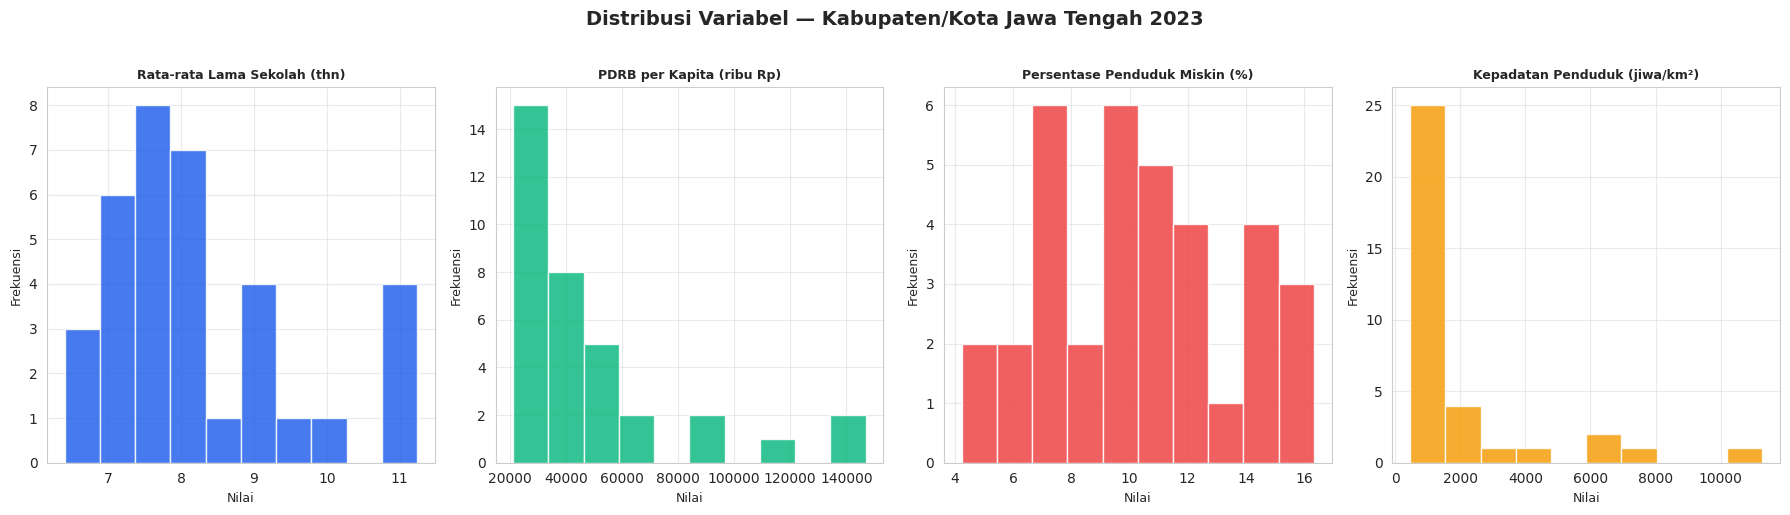

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribusi Variabel — Kabupaten/Kota Jawa Tengah 2023',
             fontsize=14, fontweight='bold', y=1.02)

for i, (col, lbl, clr) in enumerate(zip(num_cols, labels, colors)):
    axes[i].hist(df[col], color=clr, edgecolor='white', bins=10, alpha=0.85)
    axes[i].set_title(lbl, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Nilai', fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
    axes[i].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**Keterkaitan Tiap Variabel**

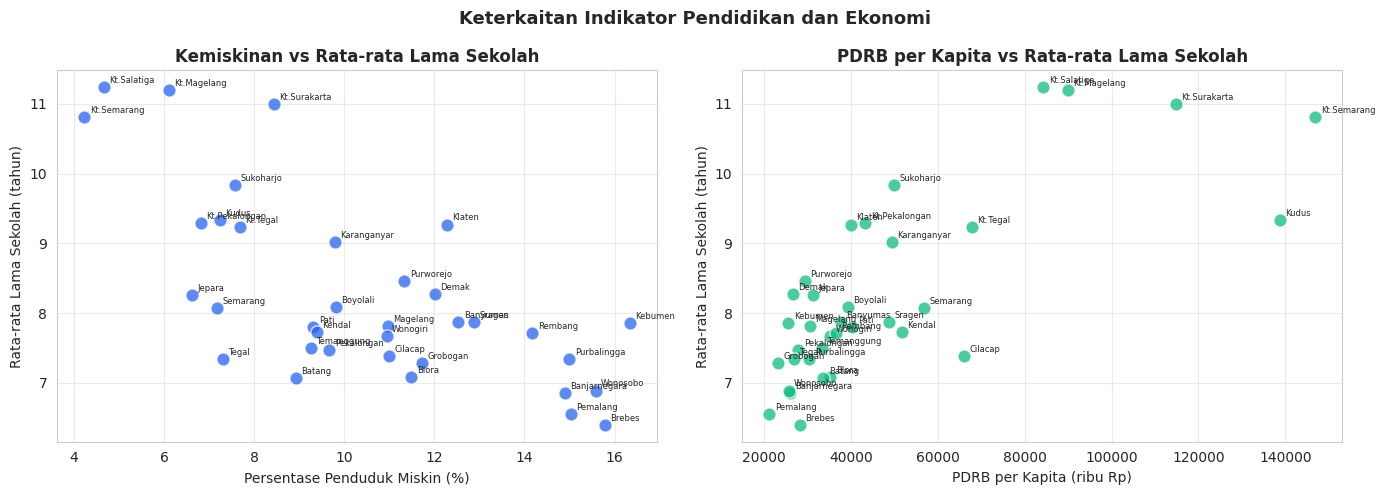

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Keterkaitan Indikator Pendidikan dan Ekonomi', fontsize=13, fontweight='bold')

# Plot 1: Kemiskinan vs RLS
axes[0].scatter(df['persen_miskin'], df['RLS'],
                color='#2563EB', edgecolor='white', alpha=0.75, s=90)
for _, row in df.iterrows():
    axes[0].annotate(row['kabupaten_kota'].replace('Kota ','Kt.'),
                     (row['persen_miskin'], row['RLS']),
                     textcoords='offset points', xytext=(4, 3), fontsize=6)
axes[0].set_title('Kemiskinan vs Rata-rata Lama Sekolah', fontweight='bold')
axes[0].set_xlabel('Persentase Penduduk Miskin (%)')
axes[0].set_ylabel('Rata-rata Lama Sekolah (tahun)')
axes[0].grid(True, alpha=0.4)

# Plot 2: PDRB vs RLS
axes[1].scatter(df['PDRB_perkapita_ribu'], df['RLS'],
                color='#10B981', edgecolor='white', alpha=0.75, s=90)
for _, row in df.iterrows():
    axes[1].annotate(row['kabupaten_kota'].replace('Kota ','Kt.'),
                     (row['PDRB_perkapita_ribu'], row['RLS']),
                     textcoords='offset points', xytext=(4, 3), fontsize=6)
axes[1].set_title('PDRB per Kapita vs Rata-rata Lama Sekolah', fontweight='bold')
axes[1].set_xlabel('PDRB per Kapita (ribu Rp)')
axes[1].set_ylabel('Rata-rata Lama Sekolah (tahun)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**HeatMap Antar Variabel**

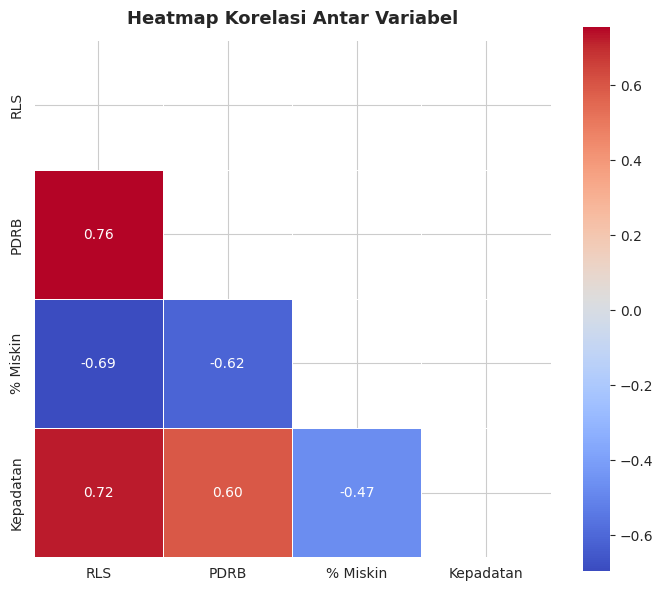

In [8]:
plt.figure(figsize=(7, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            xticklabels=['RLS','PDRB','% Miskin','Kepadatan'],
            yticklabels=['RLS','PDRB','% Miskin','Kepadatan'])
plt.title('Heatmap Korelasi Antar Variabel', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Deteksi Outlier**

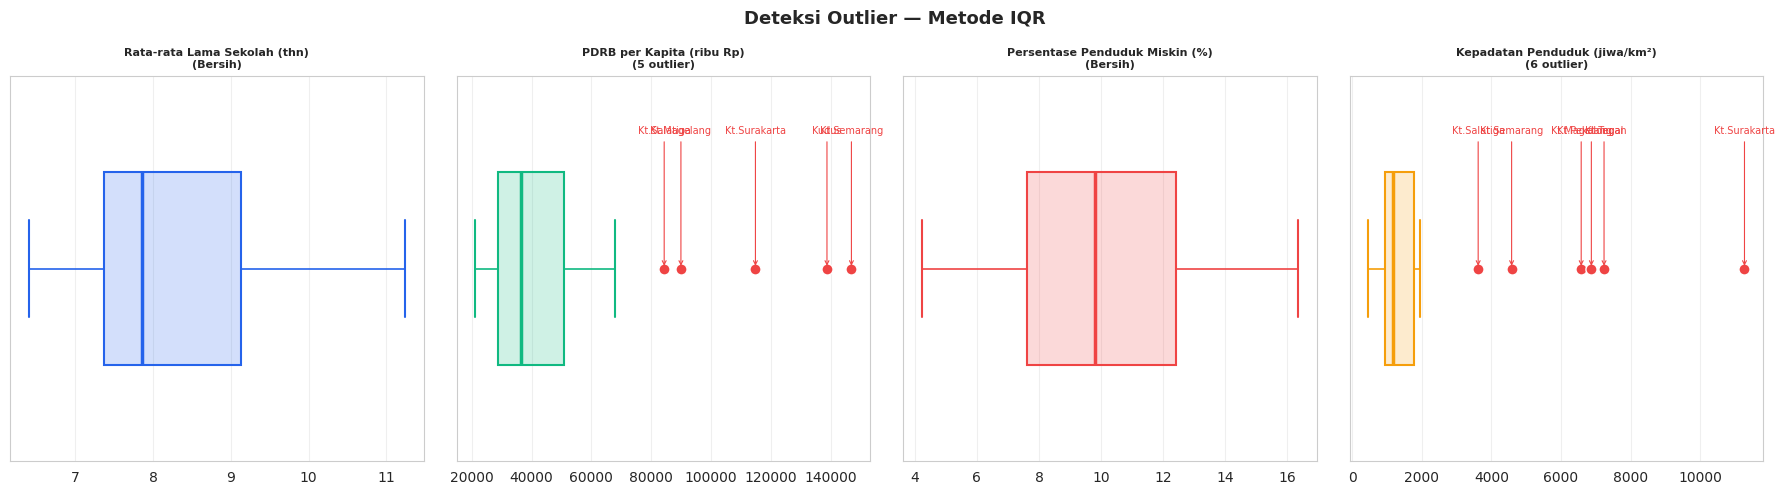

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Deteksi Outlier — Metode IQR', fontsize=13, fontweight='bold')

for i, (col, lbl, clr) in enumerate(zip(num_cols, labels, colors)):
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1; lo = Q1 - 1.5*IQR; hi = Q3 + 1.5*IQR
    out = df[(df[col] < lo) | (df[col] > hi)]

    axes[i].boxplot(df[col], vert=False, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=clr+'33', color=clr, linewidth=1.5),
                    medianprops=dict(color=clr, linewidth=2.5),
                    whiskerprops=dict(color=clr, linewidth=1.2),
                    capprops=dict(color=clr, linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='#EF4444',
                                    markeredgecolor='white', markersize=8))
    for _, row in out.iterrows():
        nm = row['kabupaten_kota'].replace('Kota ','Kt.')
        yoff = 1.35 if row[col] > df[col].median() else 0.65
        axes[i].annotate(nm, xy=(row[col], 1), xytext=(row[col], yoff),
                         fontsize=7, color='#EF4444', ha='center',
                         arrowprops=dict(arrowstyle='->', color='#EF4444', lw=0.8))
    n_out = len(out)
    status = f'{n_out} outlier' if n_out > 0 else 'Bersih'
    axes[i].set_title(f'{lbl}\n({status})', fontsize=8, fontweight='bold')
    axes[i].set_yticks([])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**STANDARISASI DATA TIAP VARIABEL**

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(df[num_cols])

df_scaled = pd.DataFrame(X, columns=num_cols)
df_scaled.insert(0, 'kabupaten_kota', df['kabupaten_kota'])

print('Data setelah StandardScaler:')
print(df_scaled.head().round(4).to_string())
print(f'\nMean setelah scaling : {X.mean(axis=0).round(6)}')
print(f'Std  setelah scaling : {X.std(axis=0).round(4)}')

Data setelah StandardScaler:
  kabupaten_kota     RLS  PDRB_perkapita_ribu  persen_miskin  kepadatan_penduduk
0        Cilacap -0.6696               0.5712         0.1843             -0.5101
1       Banyumas -0.2978              -0.3479         0.6629             -0.3191
2    Purbalingga -0.7083              -0.5814         1.4274             -0.3356
3   Banjarnegara -1.0801              -0.7250         1.3995             -0.4884
4        Kebumen -0.3056              -0.7371         1.8470             -0.4320

Mean setelah scaling : [-0.  0. -0. -0.]
Std  setelah scaling : [1. 1. 1. 1.]


# **A. Hierarchical Clustering**

**Dendrogram Hierarchical Clustering**

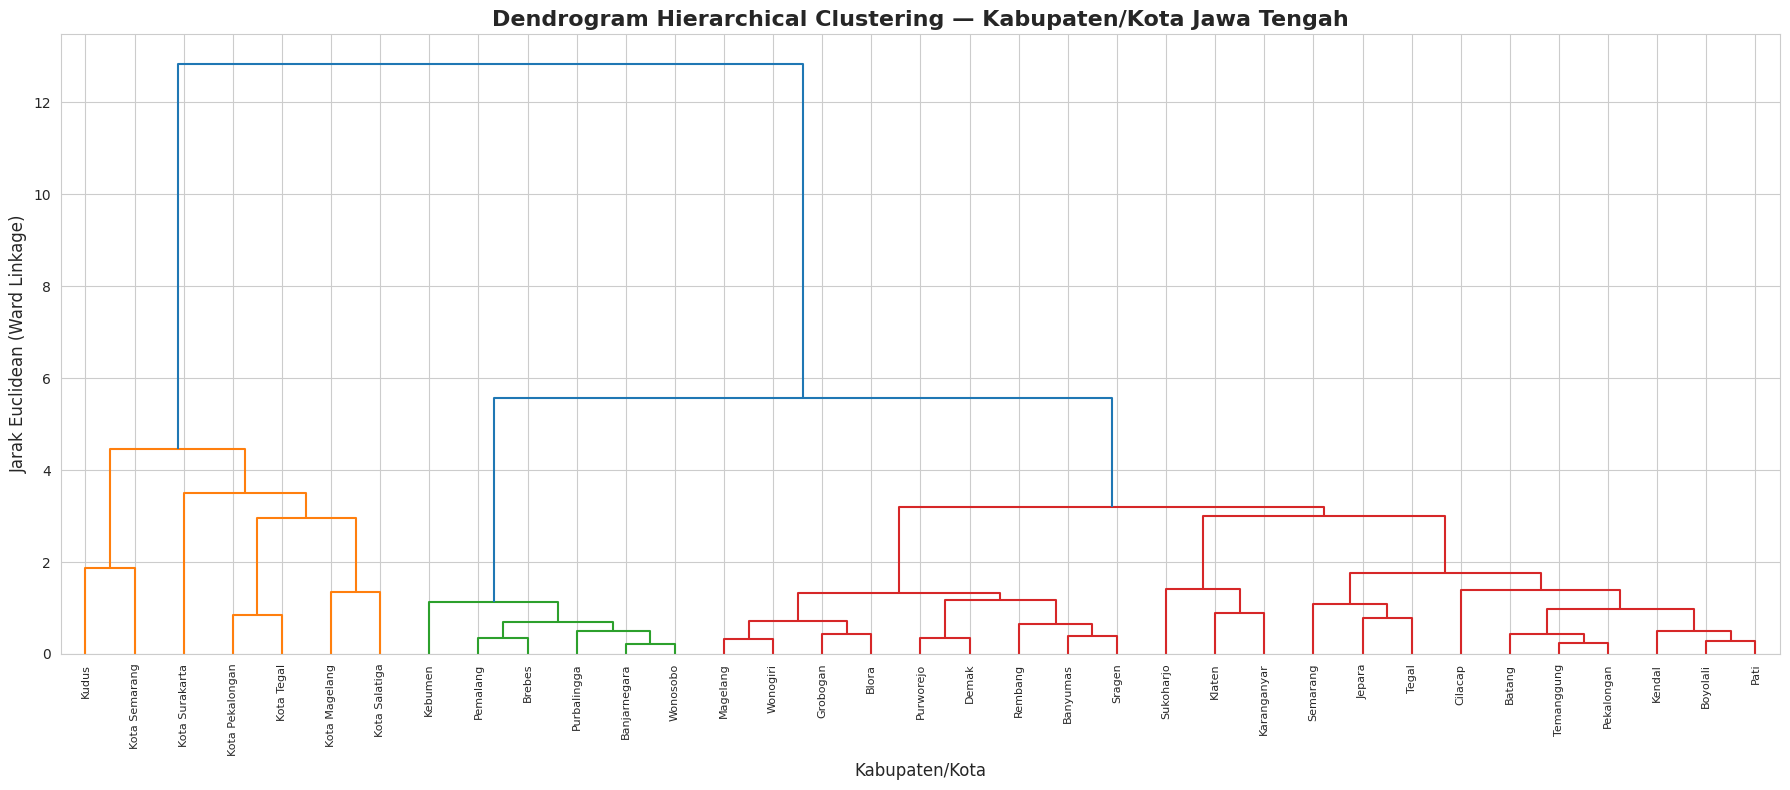

In [11]:
linked = sch.linkage(X, method='ward')

plt.figure(figsize=(18, 8))
plt.title('Dendrogram Hierarchical Clustering — Kabupaten/Kota Jawa Tengah',
          fontsize=16, fontweight='bold')
plt.xlabel('Kabupaten/Kota', fontsize=12)
plt.ylabel('Jarak Euclidean (Ward Linkage)', fontsize=12)
sch.dendrogram(linked,
               labels=df['kabupaten_kota'].values,
               leaf_rotation=90,
               leaf_font_size=8,
               color_threshold=4.5)  # ← coba nilai ini
plt.tight_layout()
plt.show()

**Dendogram dengan Garis Potong**

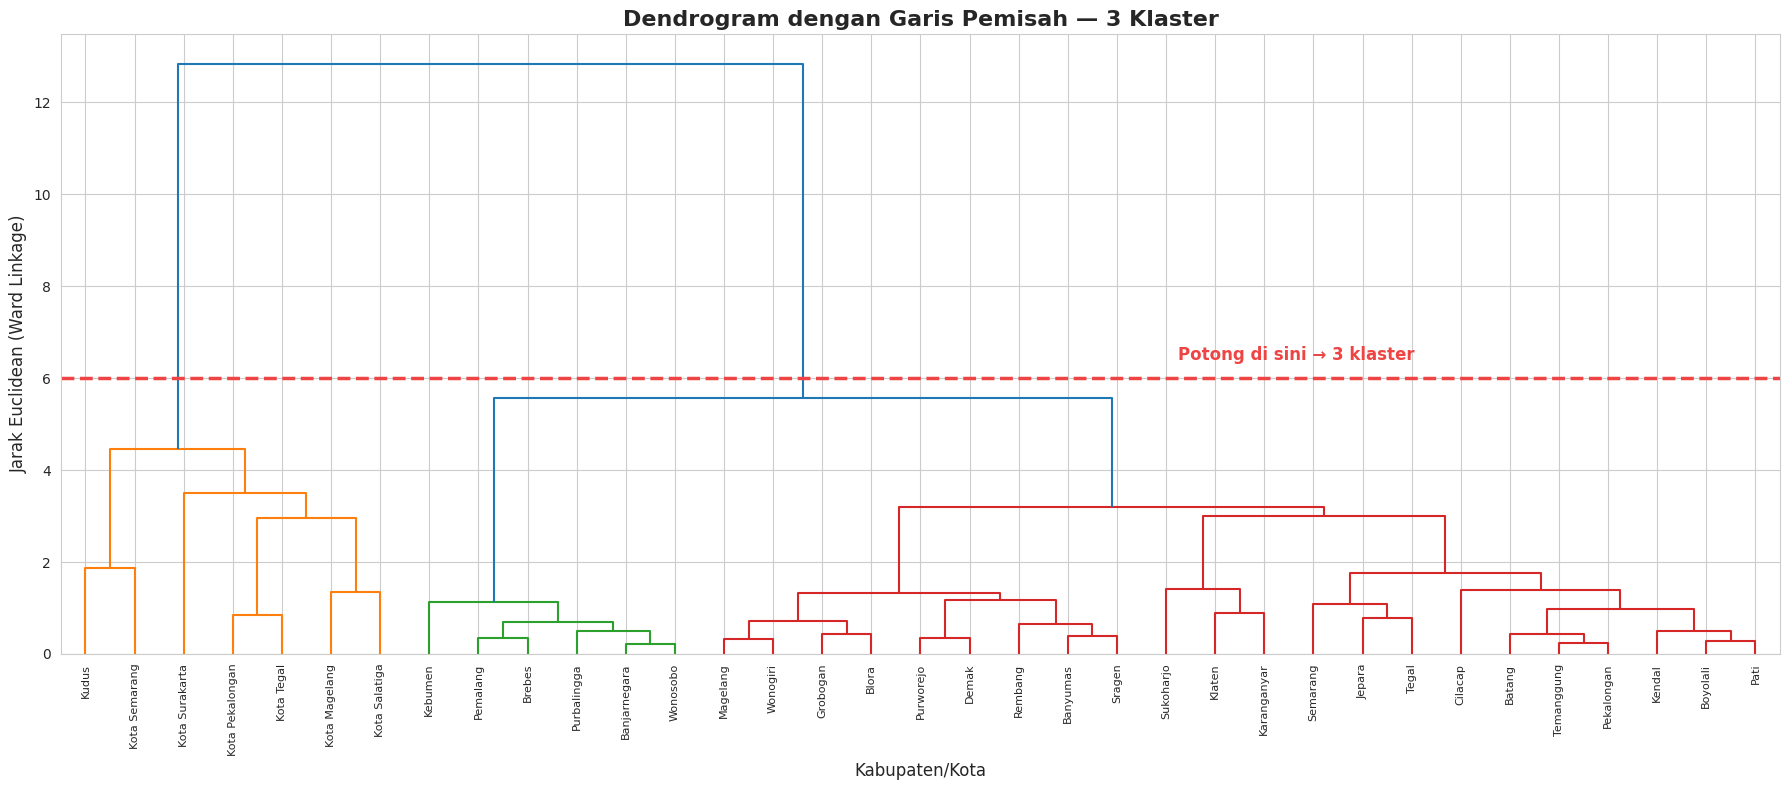

Dari dendrogram, pemotongan pada jarak ~6 menghasilkan 3 klaster yang jelas dan bermakna.


In [12]:
plt.figure(figsize=(18, 8))
plt.title('Dendrogram dengan Garis Pemisah — 3 Klaster', fontsize=16, fontweight='bold')
plt.xlabel('Kabupaten/Kota', fontsize=12)
plt.ylabel('Jarak Euclidean (Ward Linkage)', fontsize=12)
sch.dendrogram(linked, labels=df['kabupaten_kota'].values, leaf_rotation=90,
               leaf_font_size=8, color_threshold=4.5)
plt.hlines(y=6, xmin=0, xmax=len(df)*10, lw=2.5, linestyles='--', colors='#EF4444')
plt.text(x=len(df)*10*0.65, y=6.4, s='Potong di sini → 3 klaster',
         fontsize=12, color='#EF4444', fontweight='bold')
plt.tight_layout()
plt.show()
print('Dari dendrogram, pemotongan pada jarak ~6 menghasilkan 3 klaster yang jelas dan bermakna.')

**Tabel Clustering**

In [13]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)
df['HC_Cluster'] = y_hc

hc_means = df.groupby('HC_Cluster')[num_cols].mean()
print('Rata-rata variabel per klaster HC:')
print(hc_means.round(2).to_string())

hc_rls = hc_means['RLS']
label_hc_map = {
    hc_rls.idxmax(): 'Wilayah Maju',
    hc_rls.idxmin(): 'Wilayah Rentan',
    [x for x in hc_rls.index if x not in [hc_rls.idxmax(), hc_rls.idxmin()]][0]: 'Wilayah Berkembang'
}
df['HC_Label'] = df['HC_Cluster'].map(label_hc_map)

print('\nDistribusi Klaster HC:')
print(df['HC_Label'].value_counts())
print('\nDaftar Wilayah per Klaster HC:')
for lbl in ['Wilayah Maju', 'Wilayah Berkembang', 'Wilayah Rentan']:
    print(f'\n{lbl}:')
    print(df[df['HC_Label']==lbl]['kabupaten_kota'].tolist())

Rata-rata variabel per klaster HC:
              RLS  PDRB_perkapita_ribu  persen_miskin  kepadatan_penduduk
HC_Cluster                                                               
0           10.30             97950.03           6.45             6017.43
1            7.95             38588.31          10.28             1069.64
2            6.98             26170.56          15.44             1108.17

Distribusi Klaster HC:
HC_Label
Wilayah Berkembang    22
Wilayah Maju           7
Wilayah Rentan         6
Name: count, dtype: int64

Daftar Wilayah per Klaster HC:

Wilayah Maju:
['Kudus', 'Kota Magelang', 'Kota Surakarta', 'Kota Salatiga', 'Kota Semarang', 'Kota Pekalongan', 'Kota Tegal']

Wilayah Berkembang:
['Cilacap', 'Banyumas', 'Purworejo', 'Magelang', 'Boyolali', 'Klaten', 'Sukoharjo', 'Wonogiri', 'Karanganyar', 'Sragen', 'Grobogan', 'Blora', 'Rembang', 'Pati', 'Jepara', 'Demak', 'Semarang', 'Temanggung', 'Kendal', 'Batang', 'Pekalongan', 'Tegal']

Wilayah Rentan:
['Purbalingga',

**VISUALISASI SCATTERPLOT**

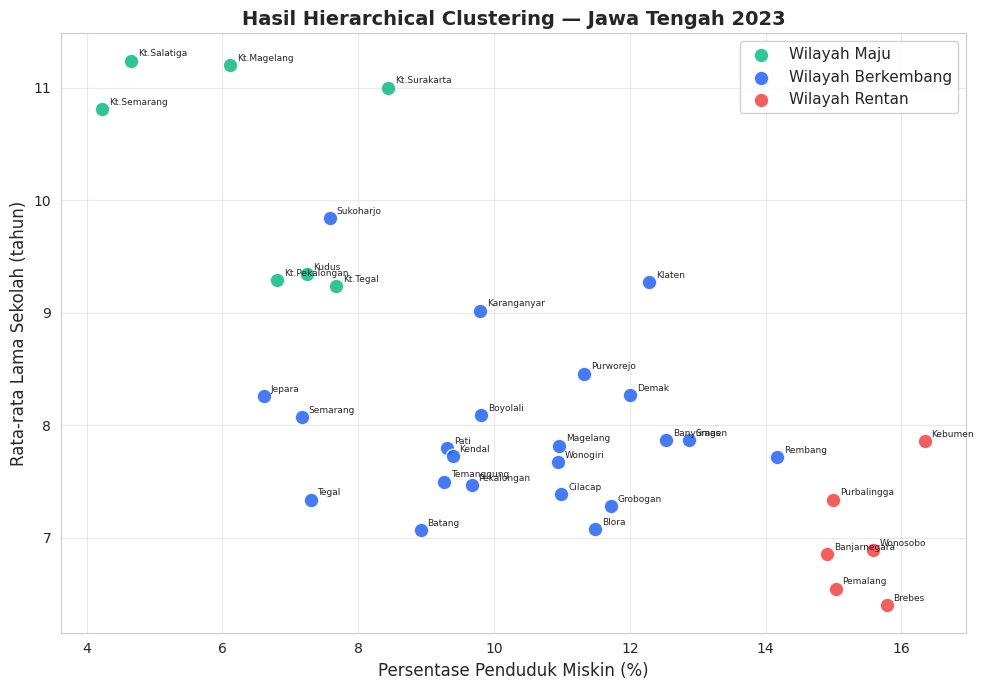

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

warna_hc = {'Wilayah Maju':'#10B981','Wilayah Berkembang':'#2563EB','Wilayah Rentan':'#EF4444'}

for lbl, clr in warna_hc.items():
    sub = df[df['HC_Label'] == lbl]
    ax.scatter(sub['persen_miskin'], sub['RLS'], color=clr,
                    label=lbl, s=110, edgecolor='white', alpha=0.85, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['kabupaten_kota'].replace('Kota ','Kt.'),
                         (row['persen_miskin'], row['RLS']),
                         textcoords='offset points', xytext=(5, 3), fontsize=6.5)

ax.set_title('Hasil Hierarchical Clustering — Jawa Tengah 2023', fontweight='bold', fontsize=14)
ax.set_xlabel('Persentase Penduduk Miskin (%)', fontsize=12)
ax.set_ylabel('Rata-rata Lama Sekolah (tahun)', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**HIERARCHICAL CLUSTERING DENGAN PETA**

In [15]:
# ── Peta Interaktif HC (Folium) ───────────────────────────────
koordinat = {
    'Cilacap':(-7.7169,108.8272),'Banyumas':(-7.5277,109.2947),
    'Purbalingga':(-7.3906,109.3653),'Banjarnegara':(-7.3870,109.6930),
    'Kebumen':(-7.6833,109.6500),'Purworejo':(-7.7167,110.0167),
    'Wonosobo':(-7.3606,109.9078),'Magelang':(-7.4797,110.2177),
    'Boyolali':(-7.5327,110.5989),'Klaten':(-7.7060,110.6017),
    'Sukoharjo':(-7.6861,110.8417),'Wonogiri':(-7.8167,110.9167),
    'Karanganyar':(-7.5969,111.0250),'Sragen':(-7.4253,111.0283),
    'Grobogan':(-7.0083,110.9150),'Blora':(-6.9625,111.4133),
    'Rembang':(-6.7067,111.3433),'Pati':(-6.7489,111.0369),
    'Kudus':(-6.8050,110.8361),'Jepara':(-6.5894,110.6681),
    'Demak':(-6.8944,110.6383),'Semarang':(-7.2333,110.4333),
    'Temanggung':(-7.3167,110.1667),'Kendal':(-6.9222,110.2019),
    'Batang':(-6.9058,109.7317),'Pekalongan':(-6.9167,109.6667),
    'Pemalang':(-6.8897,109.3814),'Tegal':(-6.9778,109.1417),
    'Brebes':(-6.8722,108.9250),'Kota Magelang':(-7.4797,110.2177),
    'Kota Surakarta':(-7.5561,110.8317),'Kota Salatiga':(-7.3305,110.5083),
    'Kota Semarang':(-6.9667,110.4167),'Kota Pekalongan':(-6.8894,109.6753),
    'Kota Tegal':(-6.8694,109.1261)
}

df['Latitude']  = df['kabupaten_kota'].map(lambda x: koordinat[x][0])
df['Longitude'] = df['kabupaten_kota'].map(lambda x: koordinat[x][1])

warna_folium_hc = {'Wilayah Maju':'green','Wilayah Berkembang':'blue','Wilayah Rentan':'red'}

m_hc = folium.Map(location=[-7.15, 110.2], zoom_start=8)

for _, row in df.iterrows():
    tooltip = (
        f"<b>{row['kabupaten_kota']}</b><br>"
        f"Klaster HC: <b>{row['HC_Label']}</b><br>"
        f"RLS: {row['RLS']} tahun<br>"
        f"PDRB/kapita: Rp {row['PDRB_perkapita_ribu']:,.0f} ribu<br>"
        f"% Miskin: {row['persen_miskin']}%<br>"
        f"Kepadatan: {row['kepadatan_penduduk']:,} jiwa/km²"
    )
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=9,
        color=warna_folium_hc[row['HC_Label']],
        fill=True,
        fill_color=warna_folium_hc[row['HC_Label']],
        fill_opacity=0.8,
        tooltip=folium.Tooltip(tooltip)
    ).add_to(m_hc)

# Legenda
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
background:white;padding:12px;border-radius:8px;border:1px solid #ccc;
font-family:Arial;font-size:13px;">
<b>Hierarchical Clustering</b><br>
<span style="color:green">●</span> Wilayah Maju<br>
<span style="color:blue">●</span> Wilayah Berkembang<br>
<span style="color:red">●</span> Wilayah Rentan
</div>'''
m_hc.get_root().html.add_child(folium.Element(legend_html))
m_hc

# **B.K-MEANS CLUSTERING**

**Elbow Method**

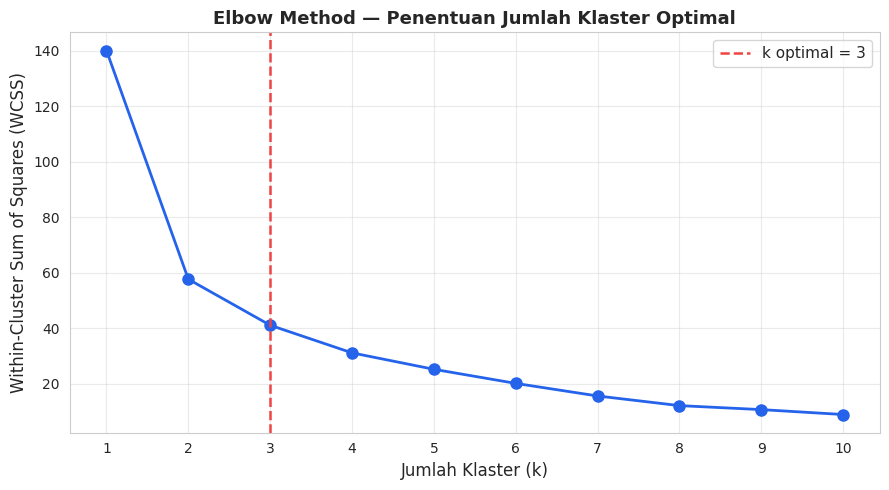

In [16]:
wcss = []
K    = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K, wcss, 'o-', color='#2563EB', linewidth=2, markersize=8)
plt.axvline(x=3, color='#EF4444', linestyle='--', lw=1.8, label='k optimal = 3')
plt.title('Elbow Method — Penentuan Jumlah Klaster Optimal', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(K)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Silhouette Score**

=== Silhouette Score per k ===
k=2 | Silhouette=0.5943
k=3 | Silhouette=0.4065
k=4 | Silhouette=0.3969
k=5 | Silhouette=0.3894
k=6 | Silhouette=0.2847
k=7 | Silhouette=0.3478

k terbaik berdasarkan Silhouette Score : k=2 (0.5943)


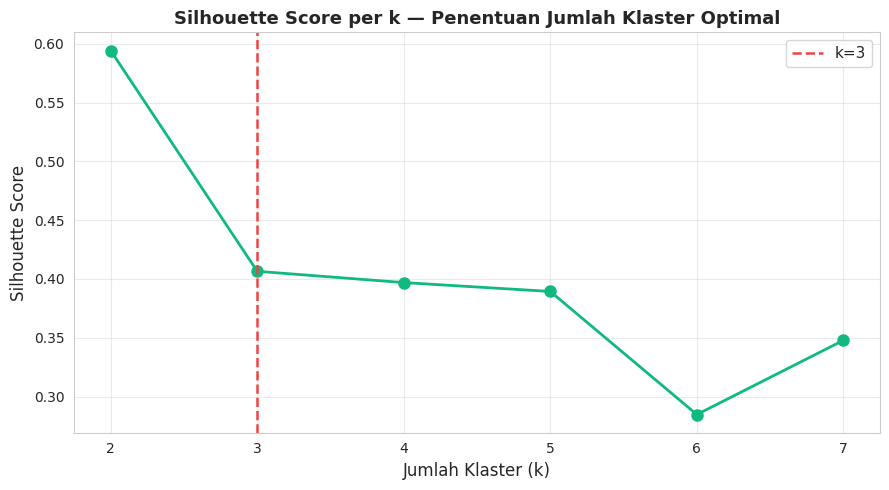

In [17]:
# ── 1. SILHOUETTE SCORE ──────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

sil_scores = []
K_range    = range(2, 8)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, lbl))

print("=== Silhouette Score per k ===")
for i, k in enumerate(K_range):
    print(f'k={k} | Silhouette={sil_scores[i]:.4f}')

best_k_sil = list(K_range)[np.argmax(sil_scores)]
print(f'\nk terbaik berdasarkan Silhouette Score : k={best_k_sil} ({max(sil_scores):.4f})')

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), sil_scores, 'o-', color='#10B981', linewidth=2, markersize=8)
plt.axvline(x=3, color='#EF4444', linestyle='--', lw=1.8, label='k=3')
plt.title('Silhouette Score per k — Penentuan Jumlah Klaster Optimal',
          fontweight='bold', fontsize=13)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**DAVIES-BOULDI**N

=== Davies-Bouldin Index per k ===
k=2 | DBI=0.7156
k=3 | DBI=0.7087
k=4 | DBI=0.7977
k=5 | DBI=0.7055
k=6 | DBI=0.9302
k=7 | DBI=0.7829

k terbaik berdasarkan Davies-Bouldin : k=5 (0.7055)


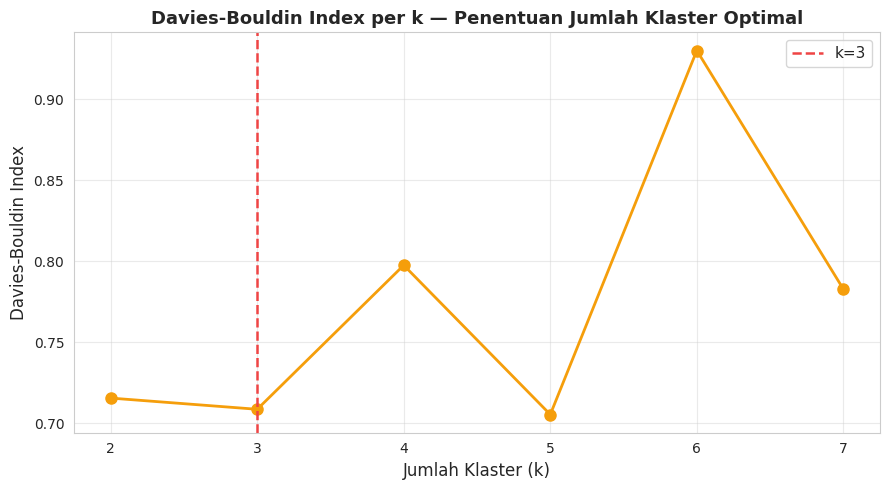

In [18]:

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np

dbi_scores = []
K_range    = range(2, 8)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    dbi_scores.append(davies_bouldin_score(X, lbl))

print("=== Davies-Bouldin Index per k ===")
for i, k in enumerate(K_range):
    print(f'k={k} | DBI={dbi_scores[i]:.4f}')

best_k_dbi = list(K_range)[np.argmin(dbi_scores)]
print(f'\nk terbaik berdasarkan Davies-Bouldin : k={best_k_dbi} ({min(dbi_scores):.4f})')

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), dbi_scores, 'o-', color='#F59E0B', linewidth=2, markersize=8)
plt.axvline(x=3, color='#EF4444', linestyle='--', lw=1.8, label='k=3')
plt.title('Davies-Bouldin Index per k — Penentuan Jumlah Klaster Optimal',
          fontweight='bold', fontsize=13)
plt.xlabel('Jumlah Klaster (k)', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Hasil Clustering dengan K-Means**

In [29]:

df_scaled_hasil = pd.DataFrame(X, columns=['RLS', 'PDRB_perkapita_ribu',
                                            'persen_miskin', 'kepadatan_penduduk'])

df_scaled_hasil.insert(0, 'kabupaten_kota', df['kabupaten_kota'].values)
df_scaled_hasil['Klaster'] = df['KM_Label'].values

df_scaled_hasil.columns = ['Kabupaten/Kota', 'RLS (scaled)',
                            'PDRB/Kapita (scaled)', '% Miskin (scaled)',
                            'Kepadatan (scaled)', 'Klaster']

df_scaled_hasil = df_scaled_hasil.sort_values('Klaster').reset_index(drop=True)

print('Hasil K-Means Clustering (k=3) — Data Terstandarisasi — Jawa Tengah 2023')
print(df_scaled_hasil.round(4).to_string(index=True))

Hasil K-Means Clustering (k=3) — Data Terstandarisasi — Jawa Tengah 2023
     Kabupaten/Kota  RLS (scaled)  PDRB/Kapita (scaled)  % Miskin (scaled)  Kepadatan (scaled)             Klaster
0           Cilacap       -0.6696                0.5712             0.1843             -0.5101  Wilayah Berkembang
1             Tegal       -0.7083               -0.6961            -0.9624             -0.1629  Wilayah Berkembang
2        Pekalongan       -0.6076               -0.6620            -0.2259             -0.3980  Wilayah Berkembang
3            Batang       -0.9174               -0.4761            -0.4590             -0.4664  Wilayah Berkembang
4            Kendal       -0.4063                0.1070            -0.3129             -0.4337  Wilayah Berkembang
5        Temanggung       -0.5844               -0.4876            -0.3533             -0.4799  Wilayah Berkembang
6          Semarang       -0.1429                0.2716            -1.0028             -0.4269  Wilayah Berkembang
7      

**K-MEANS CLUSTER dengan K=3**

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_km   = kmeans.fit_predict(X)
df['KM_Cluster'] = y_km

# Pemetaan label berdasarkan rata-rata RLS per klaster
km_means = df.groupby('KM_Cluster')[num_cols].mean()
print('Rata-rata variabel per klaster K-Means:')
print(km_means.round(2).to_string())

km_rls = km_means['RLS']
label_km_map = {
    km_rls.idxmax(): 'Wilayah Maju',
    km_rls.idxmin(): 'Wilayah Rentan',
    [x for x in km_rls.index if x not in [km_rls.idxmax(), km_rls.idxmin()]][0]: 'Wilayah Berkembang'
}
df['KM_Label'] = df['KM_Cluster'].map(label_km_map)

print('\nDistribusi Klaster K-Means:')
print(df['KM_Label'].value_counts())
print('\nDaftar Wilayah per Klaster K-Means:')
for lbl in ['Wilayah Maju', 'Wilayah Berkembang', 'Wilayah Rentan']:
    print(f'\n{lbl}:')
    print(df[df['KM_Label']==lbl]['kabupaten_kota'].tolist())

Rata-rata variabel per klaster K-Means:
              RLS  PDRB_perkapita_ribu  persen_miskin  kepadatan_penduduk
KM_Cluster                                                               
0            7.09             27653.48          15.26             1040.71
1           10.30             97950.03           6.45             6017.43
2            7.96             38685.33          10.09             1090.29

Distribusi Klaster K-Means:
KM_Label
Wilayah Berkembang    21
Wilayah Rentan         7
Wilayah Maju           7
Name: count, dtype: int64

Daftar Wilayah per Klaster K-Means:

Wilayah Maju:
['Kudus', 'Kota Magelang', 'Kota Surakarta', 'Kota Salatiga', 'Kota Semarang', 'Kota Pekalongan', 'Kota Tegal']

Wilayah Berkembang:
['Cilacap', 'Banyumas', 'Purworejo', 'Magelang', 'Boyolali', 'Klaten', 'Sukoharjo', 'Wonogiri', 'Karanganyar', 'Sragen', 'Grobogan', 'Blora', 'Pati', 'Jepara', 'Demak', 'Semarang', 'Temanggung', 'Kendal', 'Batang', 'Pekalongan', 'Tegal']

Wilayah Rentan:
['Purbaling

**Visualisasi K-Means: Scatter Plot + Centroid**

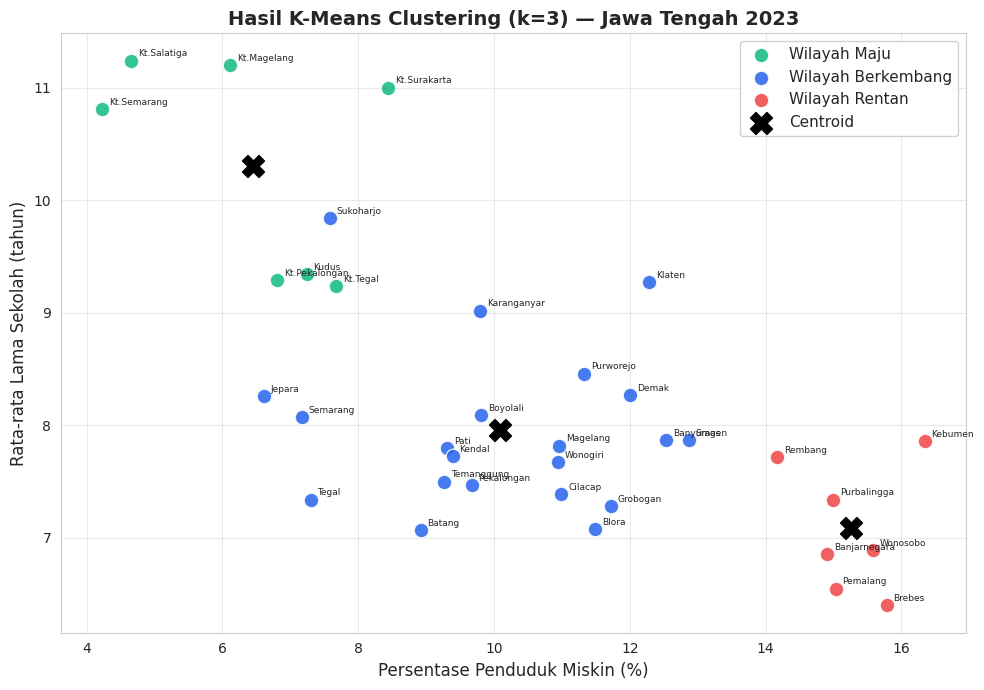

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 7)) # Changed to 1,1 subplot and adjusted figsize for single plot

warna_km = {'Wilayah Maju':'#10B981','Wilayah Berkembang':'#2563EB','Wilayah Rentan':'#EF4444'}

# Scatter Plot KM
for lbl, clr in warna_km.items():
    sub = df[df['KM_Label'] == lbl]
    ax.scatter(sub['persen_miskin'], sub['RLS'], color=clr,
                    label=lbl, s=110, edgecolor='white', alpha=0.85, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['kabupaten_kota'].replace('Kota ','Kt.'),
                         (row['persen_miskin'], row['RLS']),
                         textcoords='offset points', xytext=(5,3), fontsize=6.5)

# Plot centroid
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
miskin_idx = num_cols.index('persen_miskin')
rls_idx    = num_cols.index('RLS')
ax.scatter(centroids_orig[:, miskin_idx], centroids_orig[:, rls_idx],
                s=250, c='black', marker='X', zorder=5, label='Centroid')

ax.set_title('Hasil K-Means Clustering (k=3) — Jawa Tengah 2023', fontweight='bold', fontsize=14)
ax.set_xlabel('Persentase Penduduk Miskin (%)', fontsize=12)
ax.set_ylabel('Rata-rata Lama Sekolah (tahun)', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [22]:
# ── Peta Interaktif K-Means (Folium) ─────────────────────────
warna_folium_km = {'Wilayah Maju':'green','Wilayah Berkembang':'blue','Wilayah Rentan':'red'}

m_km = folium.Map(location=[-7.15, 110.2], zoom_start=8)

for _, row in df.iterrows():
    tooltip = (
        f"<b>{row['kabupaten_kota']}</b><br>"
        f"Klaster KMeans: <b>{row['KM_Label']}</b><br>"
        f"RLS: {row['RLS']} tahun<br>"
        f"PDRB/kapita: Rp {row['PDRB_perkapita_ribu']:,.0f} ribu<br>"
        f"% Miskin: {row['persen_miskin']}%<br>"
        f"Kepadatan: {row['kepadatan_penduduk']:,} jiwa/km²"
    )
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=9,
        color=warna_folium_km[row['KM_Label']],
        fill=True,
        fill_color=warna_folium_km[row['KM_Label']],
        fill_opacity=0.8,
        tooltip=folium.Tooltip(tooltip)
    ).add_to(m_km)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
background:white;padding:12px;border-radius:8px;border:1px solid #ccc;
font-family:Arial;font-size:13px;">
<b>K-Means Clustering</b><br>
<span style="color:green">●</span> Wilayah Maju<br>
<span style="color:blue">●</span> Wilayah Berkembang<br>
<span style="color:red">●</span> Wilayah Rentan
</div>'''
m_km.get_root().html.add_child(folium.Element(legend_html))
m_km

# **C.EVALUASI DAN PERBANDINGAN MODEL**

**Metrik Evaluasi Kedua Metode**

In [23]:
sil_hc  = silhouette_score(X, y_hc)
dbi_hc  = davies_bouldin_score(X, y_hc)
sil_km  = silhouette_score(X, y_km)
dbi_km  = davies_bouldin_score(X, y_km)

hasil_eval = pd.DataFrame({
    'Metode'              : ['Hierarchical Clustering (Ward)', 'K-Means (k=3)'],
    'Silhouette Score'    : [round(sil_hc, 4), round(sil_km, 4)],
    'Davies-Bouldin Index': [round(dbi_hc, 4), round(dbi_km, 4)],
    'Jumlah Klaster'      : [3, 3]
})
print('=== PERBANDINGAN METRIK EVALUASI CLUSTERING ===')
print(hasil_eval.to_string(index=False))
print()
print('Interpretasi:')
print('  Silhouette Score : Semakin tinggi semakin baik (mendekati 1)')
print('  Davies-Bouldin   : Semakin rendah semakin baik (mendekati 0)')
metode_terbaik = 'Hierarchical Clustering' if sil_hc > sil_km else 'K-Means'
print(f'\nKesimpulan: {metode_terbaik} menghasilkan klaster yang lebih optimal.')

=== PERBANDINGAN METRIK EVALUASI CLUSTERING ===
                        Metode  Silhouette Score  Davies-Bouldin Index  Jumlah Klaster
Hierarchical Clustering (Ward)            0.4010                0.6962               3
                 K-Means (k=3)            0.4065                0.7087               3

Interpretasi:
  Silhouette Score : Semakin tinggi semakin baik (mendekati 1)
  Davies-Bouldin   : Semakin rendah semakin baik (mendekati 0)

Kesimpulan: K-Means menghasilkan klaster yang lebih optimal.


**Visualisasi Perbandingan Cluster**

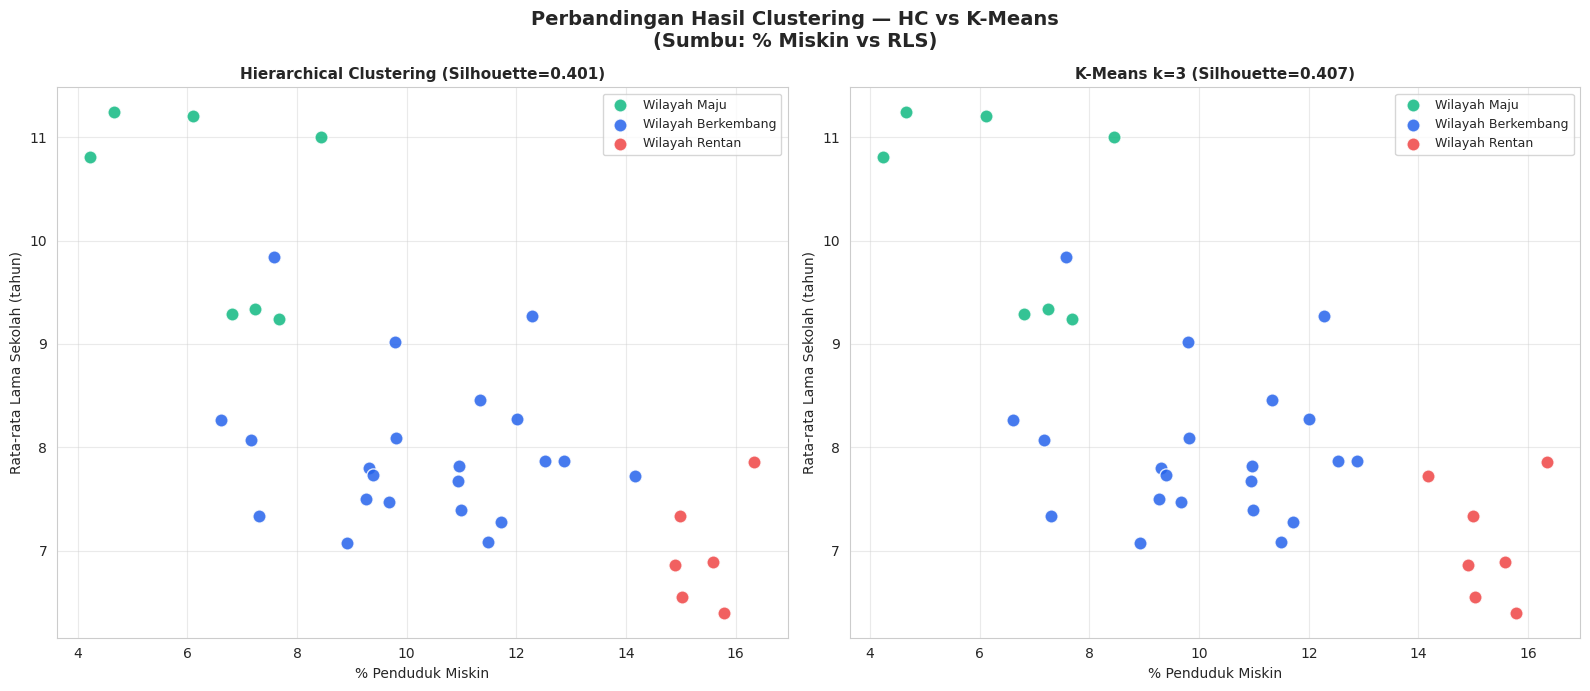

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perbandingan Hasil Clustering — HC vs K-Means\n(Sumbu: % Miskin vs RLS)',
             fontsize=14, fontweight='bold')

for ax, label_col, title in zip(axes,
    ['HC_Label', 'KM_Label'],
    [f'Hierarchical Clustering (Silhouette={sil_hc:.3f})',
     f'K-Means k=3 (Silhouette={sil_km:.3f})']):
    warna = {'Wilayah Maju':'#10B981','Wilayah Berkembang':'#2563EB','Wilayah Rentan':'#EF4444'}
    for lbl, clr in warna.items():
        sub = df[df[label_col] == lbl]
        ax.scatter(sub['persen_miskin'], sub['RLS'], color=clr,
                   label=lbl, s=90, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('% Penduduk Miskin', fontsize=10)
    ax.set_ylabel('Rata-rata Lama Sekolah (tahun)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**Tabel Perbandingan Anggota Klaster (Konsistensi)**

In [25]:
comparison = df[['kabupaten_kota', 'HC_Label', 'KM_Label']].copy()
comparison['Konsisten'] = comparison['HC_Label'] == comparison['KM_Label']

n_konsisten = comparison['Konsisten'].sum()
n_total     = len(comparison)
pct_konsisten = n_konsisten / n_total * 100

print(f'=== KONSISTENSI PENGELOMPOKAN HC vs K-Means ===')
print(f'Wilayah konsisten : {n_konsisten}/{n_total} ({pct_konsisten:.1f}%)')
print()
print('Wilayah TIDAK konsisten antara dua metode:')
print(comparison[~comparison['Konsisten']].to_string(index=False))

=== KONSISTENSI PENGELOMPOKAN HC vs K-Means ===
Wilayah konsisten : 34/35 (97.1%)

Wilayah TIDAK konsisten antara dua metode:
kabupaten_kota           HC_Label       KM_Label  Konsisten
       Rembang Wilayah Berkembang Wilayah Rentan      False


**Tabel Karakteristik Perbandingan Cluster**

In [26]:
col_rename = {'RLS':'RLS (thn)', 'PDRB_perkapita_ribu':'PDRB/kap (rb Rp)',
              'persen_miskin':'% Miskin', 'kepadatan_penduduk':'Kepadatan (jiwa/km²)'}

print('=== KARAKTERISTIK KLASTER — HIERARCHICAL CLUSTERING ===')
hc_char = df.groupby('HC_Label')[num_cols].mean().round(2).rename(columns=col_rename)
print(hc_char.to_string())

print('\n=== KARAKTERISTIK KLASTER — K-MEANS ===')
km_char = df.groupby('KM_Label')[num_cols].mean().round(2).rename(columns=col_rename)
print(km_char.to_string())

print('\n=== JUMLAH ANGGOTA PER KLASTER ===')
count_comp = pd.DataFrame({
    'HC' : df['HC_Label'].value_counts(),
    'K-Means' : df['KM_Label'].value_counts()
})
print(count_comp.to_string())

=== KARAKTERISTIK KLASTER — HIERARCHICAL CLUSTERING ===
                    RLS (thn)  PDRB/kap (rb Rp)  % Miskin  Kepadatan (jiwa/km²)
HC_Label                                                                       
Wilayah Berkembang       7.95          38588.31     10.28               1069.64
Wilayah Maju            10.30          97950.03      6.45               6017.43
Wilayah Rentan           6.98          26170.56     15.44               1108.17

=== KARAKTERISTIK KLASTER — K-MEANS ===
                    RLS (thn)  PDRB/kap (rb Rp)  % Miskin  Kepadatan (jiwa/km²)
KM_Label                                                                       
Wilayah Berkembang       7.96          38685.33     10.09               1090.29
Wilayah Maju            10.30          97950.03      6.45               6017.43
Wilayah Rentan           7.09          27653.48     15.26               1040.71

=== JUMLAH ANGGOTA PER KLASTER ===
                    HC  K-Means
Wilayah Berkembang  22       21
Wil

In [28]:
print(df.columns)

Index(['kabupaten_kota', 'kategori', 'RLS', 'PDRB_perkapita_ribu',
       'persen_miskin', 'kepadatan_penduduk', 'HC_Cluster', 'HC_Label',
       'Latitude', 'Longitude', 'KM_Cluster', 'KM_Label'],
      dtype='object')
